# 🏡 Dataset: Usecase 7 - Football Players Transfer Fee Prediction
# 📅 Date: 2025-03-03
# ✍️ Author: Sultan 

## Import Libraries

In [134]:
# To ignore warnings
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

from sklearn import metrics

%matplotlib inline

## Load the Data

In [135]:
#Read in the csv file and convert to a Pandas dataframe
football = pd.read_csv('Data/final_data.csv')

In [136]:
print(f"The shape is:{football.shape}")

The shape is:(10754, 22)


In [137]:
football.describe(include="object").T

,count,unique,top,freq
player,10754,10754,/david-de-gea/profil/spieler/59377,1
team,10754,374,Daejeon Hana Citizen,46
name,10754,10584,Paulinho,6
position,10754,16,Defender Centre-Back,1821


## Preprocess the Data

## 1. Data Profiling:
Data profiling is a comprehensive process of examining the data available in an existing dataset and collecting statistics and information about that data. 

In [138]:
football.head(10)

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,...,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
0,/david-de-gea/profil/spieler/59377,Manchester United,David de Gea,Goalkeeper,189.0,32.0,104,0.000000,0.000000,0.009585,...,1.217252,0.335463,9390,42,5,13,15000000,70000000,1,0
1,/jack-butland/profil/spieler/128899,Manchester United,Jack Butland,Goalkeeper,196.0,30.0,15,0.000000,0.000000,0.069018,...,1.242331,0.207055,1304,510,58,1,1500000,22000000,1,0
2,/tom-heaton/profil/spieler/34130,Manchester United,Tom Heaton,Goalkeeper,188.0,37.0,4,0.000000,0.000000,0.000000,...,0.616438,0.924658,292,697,84,4,600000,6000000,1,0
3,/lisandro-martinez/profil/spieler/480762,Manchester United,Lisandro Martínez,Defender Centre-Back,175.0,25.0,82,0.028090,0.056180,0.224719,...,0.000000,0.000000,6408,175,22,9,50000000,50000000,2,0
4,/raphael-varane/profil/spieler/164770,Manchester United,Raphaël Varane,Defender Centre-Back,191.0,30.0,63,0.017889,0.017889,0.053667,...,0.000000,0.000000,5031,238,51,21,40000000,80000000,2,0
5,/harry-maguire/profil/spieler/177907,Manchester United,Harry Maguire,Defender Centre-Back,194.0,30.0,68,0.037799,0.000000,0.302394,...,0.000000,0.000000,4762,148,27,1,25000000,70000000,2,0
6,/victor-lindelof/profil/spieler/184573,Manchester United,Victor Lindelöf,Defender Centre-Back,187.0,28.0,70,0.000000,0.032901,0.115153,...,0.000000,0.000000,5471,95,19,10,15000000,35000000,2,0
7,/phil-jones/profil/spieler/117996,Manchester United,Phil Jones,Defender Centre-Back,185.0,31.0,8,0.000000,0.000000,0.216346,...,0.000000,0.000000,416,932,169,7,2000000,20000000,2,0
8,/teden-mengi/profil/spieler/548470,Manchester United,Teden Mengi,Defender Centre-Back,186.0,21.0,34,0.000000,0.000000,0.130529,...,0.000000,0.000000,2758,47,13,0,2000000,2000000,2,0
9,/luke-shaw/profil/spieler/183288,Manchester United,Luke Shaw,Defender Left-Back,178.0,27.0,74,0.015374,0.169115,0.353604,...,0.000000,0.000000,5854,443,70,4,35000000,42000000,2,1


In [139]:
football['player'][0]

'/david-de-gea/profil/spieler/59377'

In [140]:
# Player Information  
# Name: Full name of the player Ex: (Lionel Messi The Goat).  
# Player ID: A unique identifier for the player, represented as a URL (/david-de-gea/profil/spieler/59377).  
# Team: The club the player currently plays for Ex: (Real Madrid).  
# Position: The primary position the player plays in (Goalkeeper, Defender, Midfielder, Forward).  
# Height: The player's height in cm.  
# Age: The player's age.  

# Performance Statistics  
# Appearances: Total matches played.  
# Goals: Total number of goals scored.  
# Assists: Number of assists provided.  
# Yellow Cards: Number of yellow cards received.  
# Second Yellow Cards: Number of times the player has received a second yellow (leading to a red card).  
# Red Cards: Number of direct red cards received.  

# Goalkeeper-Specific Stats (Applicable only to goalkeepers).
# Goals Conceded (Per Match): Average number of goals the player concedes per game.  
# Clean Sheets: Number of matches where the goalkeeper did not concede any goals.  

# Playing Time & Injuries  
# Minutes Played: Total minutes spent on the field (10 to 10,000+).  
# Days Injured: Number of days the player has been unavailable due to injuries.  
# Games Missed Due to Injury: Number of matches the player missed because of injuries.  

# Achievements & Market Value  
# Awards Won: Number of individual awards the player has received.  
# Current Market Value (€): The player’s estimated current market worth.  
# Highest Market Value (€): The highest recorded market value of the player.  

# Position Encoding & Winger Status  
# Position Encoding: A numerical representation of the player’s role:  
#   1 = Goalkeeper  
#   2 = Defender  
#   3 = Midfielder  
#   4 = Forward  
# Winger: Indicates whether the player primarily plays as a winger with two value (0 = No , 1 = Yes). 


#### 1. Reliability:
Evaluate the data's source and collection process to determine its trustworthiness.
__________________

In [141]:
# The Data Source is Transfermarkt: https://www.transfermarkt.com/ and it's a well-known football statistics and transfer market website.
# Which is leading us to indicate that Source is trustworthy in other word it's it's Reliabe.

#### 2. Timeliness: 
Ensure the data is up-to-date and reflective of the current situation or the period of interest for the analysis.
_____________

In [142]:
# The data spans across the 2021-2022 and 2022-2023 seasons, providing relevant context for predicting player transfer prices.  

#### 3. Consistency: 

Confirm that the data is consistent within the dataset and across multiple data sources. For example, the same data point should not have different values in different places.
____________


In [143]:
# Consistency in this dataset is maintained through standardized player metrics, ensuring uniformity in how data is recorded across seasons.  
# The player statistics, including goals, assists, injuries, and awards, are consistently represented, allowing for accurate comparisons and analysis over time.

#### 4. Relevance: 
_____________

In [144]:
# The dataset is highly relevant for analysis as it captures player performance metrics from the 2021-2023 seasons.

#### 5. Uniqueness: 
Check for and remove duplicate records to prevent skewed analysis results.
______________

In [145]:
# Display the duplicate rows and make sure there no duplicate rows accross the dataset
football[football.duplicated()]

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,...,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger


In [146]:
# Display the duplicate rows and make sure there no duplicate rows accross the dataset
football[football['player'].duplicated()]

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,...,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger


In [147]:
# Display the duplicate rows and make sure there no duplicate rows accross the dataset
football[football.duplicated(['name', 'position'], keep=False)].head(5)

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,...,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
380,/rhys-williams/profil/spieler/503679,Liverpool FC,Rhys Williams,Defender Centre-Back,195.0,22.0,39,0.093232,0.062155,0.248619,...,0.0,0.0,2896,50,10,0,3000000,5000000,2,0
385,/fabinho/profil/spieler/225693,Liverpool FC,Fabinho,midfield-DefensiveMidfield,188.0,29.0,97,0.099571,0.037339,0.273821,...,0.0,0.0,7231,140,29,8,45000000,70000000,3,0
1052,/andre-silva/profil/spieler/198008,RB Leipzig,André Silva,Attack Centre-Forward,185.0,27.0,95,0.403379,0.263748,0.077573,...,0.0,0.0,5801,221,15,4,20000000,45000000,4,0
1107,/luiz-felipe/profil/spieler/457931,Real Betis Balompié,Luiz Felipe,Defender Centre-Back,187.0,26.0,70,0.000000,0.015712,0.282821,...,0.0,0.0,5728,318,49,3,15000000,22000000,2,0
1194,/fernando/profil/spieler/51174,Sevilla FC,Fernando,midfield-DefensiveMidfield,183.0,35.0,68,0.017199,0.034397,0.171985,...,0.0,0.0,5233,516,75,19,3000000,17500000,3,0


In [148]:
# Display the duplicate rows and make sure there no duplicate rows accross the dataset
football[football.duplicated(['name', 'position', 'team'], keep=False)]

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,...,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger


In [149]:
# The dataset reflects player transfers between the 2021-2022 and 2022-2023 seasons, with players appearing multiple times for different teams.  
# Each record represents a unique player-team-season combination, and no exact duplicate rows were found, ensuring accurate tracking of transfers.
# Thefore, The dataset is free of duplicate rows, ensuring data integrity and consistency throughout the analysis.

#### 6. Completeness: 
Ensure that no critical data is missing. This might mean checking for null values or required fields that are empty.
___________

In [150]:
# Display number missing values per column
football.isnull().sum()

player                 0
team                   0
name                   0
position               0
height                 0
age                    0
appearance             0
goals                  0
assists                0
yellow cards           0
second yellow cards    0
red cards              0
goals conceded         0
clean sheets           0
minutes played         0
days_injured           0
games_injured          0
award                  0
current_value          0
highest_value          0
position_encoded       0
winger                 0
dtype: int64

In [151]:
# The is dataset Clean and have no NaN values

#### 7. Check Accuracy:

Verify that the data is correct and precise. This could involve comparing data samples with known sources or using validation rules.


In [152]:
# check columns types 
football.dtypes

player                  object
team                    object
name                    object
position                object
height                 float64
age                    float64
appearance               int64
goals                  float64
assists                float64
yellow cards           float64
second yellow cards    float64
red cards              float64
goals conceded         float64
clean sheets           float64
minutes played           int64
days_injured             int64
games_injured            int64
award                    int64
current_value            int64
highest_value            int64
position_encoded         int64
winger                   int64
dtype: object

In [153]:
# Filter players whose current value is 0 but had a nonzero highest value in the past
football[(football['current_value'] == 0)]#.value_counts().sum()

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,...,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
29,/mason-greenwood/profil/spieler/532826,Manchester United,Mason Greenwood,Attack-RightWinger,181.000000,21.000000,24,0.317647,0.105882,0.105882,...,0.0,0.0,1700,135,12,0,0,50000000,4,1
406,/sven-botman/profil/spieler/361093,Newcastle United,Sven Botman,Defender Centre-Back,195.000000,23.000000,76,0.041159,0.013720,0.123476,...,0.0,0.0,6560,118,19,4,0,0,2,0
407,/fabian-schar/profil/spieler/135343,Newcastle United,Fabian Schär,Defender Centre-Back,186.000000,31.000000,67,0.045678,0.076129,0.182710,...,0.0,0.0,5911,285,30,3,0,0,2,0
408,/jamaal-lascelles/profil/spieler/183318,Newcastle United,Jamaal Lascelles,Defender Centre-Back,188.000000,29.000000,38,0.068992,0.000000,0.310464,...,0.0,0.0,2609,418,57,2,0,0,2,0
409,/matt-targett/profil/spieler/250478,Newcastle United,Matt Targett,Defender Left-Back,183.000000,27.000000,54,0.023747,0.023747,0.094987,...,0.0,0.0,3790,380,66,0,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10581,/zahi-addis/profil/spieler/1069563,Brisbane Roar,Zahi Addis,Defender Left-Back,181.240353,19.000000,0,0.000000,0.000000,0.000000,...,0.0,0.0,0,0,0,0,0,0,2,1
10586,/james-murphy/profil/spieler/1069560,Brisbane Roar,James Murphy,midfield,181.240353,17.000000,0,0.000000,0.000000,0.000000,...,0.0,0.0,0,0,0,0,0,0,3,0
10587,/riley-gill/profil/spieler/1069561,Brisbane Roar,Riley Gill,midfield,181.240353,26.041903,0,0.000000,0.000000,0.000000,...,0.0,0.0,0,0,0,0,0,0,3,0
10686,/corey-hollman/profil/spieler/890186,Sydney FC,Corey Hollman,midfield-DefensiveMidfield,181.240353,19.000000,1,0.000000,0.000000,0.000000,...,0.0,0.0,3,0,0,0,0,0,3,0


In [154]:
# Filter players whose current value is 0 but had a nonzero highest value in the past
football[(football['current_value'] == 0) & (football['highest_value'] != 0)]#.value_counts().sum()

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,...,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
29,/mason-greenwood/profil/spieler/532826,Manchester United,Mason Greenwood,Attack-RightWinger,181.000000,21.0,24,0.317647,0.105882,0.105882,...,0.000000,0.0,1700,135,12,0,0,50000000,4,1
440,/benjamin-mendy/profil/spieler/157495,Manchester City,Benjamin Mendy,Defender Left-Back,185.000000,28.0,2,0.000000,0.000000,0.000000,...,0.000000,0.0,169,696,121,13,0,45000000,2,1
1738,/orji-okwonkwo/profil/spieler/401935,Bologna FC 1909,Orji Okwonkwo,Attack-RightWinger,180.000000,25.0,21,0.478088,0.119522,0.119522,...,0.000000,0.0,1506,143,22,2,0,2000000,4,1
1751,/armando-izzo/profil/spieler/32113,AC Monza,Armando Izzo,Defender Centre-Back,183.000000,31.0,44,0.028754,0.028754,0.402556,...,0.000000,0.0,3130,242,43,1,0,25000000,2,0
2101,/mohamed-ihattaren/profil/spieler/503638,Juventus FC,Mohamed Ihattaren,midfield-AttackingMidfield,183.000000,21.0,6,1.304348,0.652174,0.000000,...,0.000000,0.0,276,0,0,3,0,22000000,3,0
3422,/marcos-vinicius/profil/spieler/594006,Coritiba Foot Ball Club,Marcos Vinícius,Defender Right-Back,176.000000,26.0,3,0.000000,0.000000,0.720000,...,0.000000,0.0,125,39,8,0,0,175000,2,1
3504,/henrique-dourado/profil/spieler/270959,Cruzeiro Esporte Clube,Henrique Dourado,Attack Centre-Forward,186.000000,33.0,7,0.346154,0.000000,0.346154,...,0.000000,0.0,260,220,19,1,0,4000000,4,0
3550,/patric-calmon/profil/spieler/373192,Cuiabá Esporte Clube (MT),Patric Calmon,Defender Left-Back,181.000000,28.0,6,0.000000,0.000000,0.242588,...,0.000000,0.0,371,0,0,0,0,100000,2,1
7462,/cj-fodrey/profil/spieler/881090,Austin FC,CJ Fodrey,Attack Centre-Forward,188.000000,19.0,13,0.120643,0.000000,0.482574,...,0.000000,0.0,746,32,0,0,0,25000,4,0
8233,/sebastian-villa/profil/spieler/493000,CA Boca Juniors,Sebastián Villa,Attack-LeftWinger,179.000000,27.0,20,0.000000,0.117955,0.058978,...,0.000000,0.0,1526,67,15,8,0,10000000,4,1


In [155]:
# Drop players where both current_value and highest_value are 0
football = football[~((football['current_value'] == 0) & (football['highest_value'] == 0))]

# Players with current_value = 0 but highest_value ≠ 0 may be due to penalties

In [156]:
# Add a new column 'penalty_flag' to indicate possible penalties
football['penalty_flag'] = ((football['current_value'] == 0) & (football['highest_value'] != 0)).astype(int)
football[(football['current_value'] == 0) & (football['highest_value'] != 0)].head()

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,...,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger,penalty_flag
29,/mason-greenwood/profil/spieler/532826,Manchester United,Mason Greenwood,Attack-RightWinger,181.0,21.0,24,0.317647,0.105882,0.105882,...,0.0,1700,135,12,0,0,50000000,4,1,1
440,/benjamin-mendy/profil/spieler/157495,Manchester City,Benjamin Mendy,Defender Left-Back,185.0,28.0,2,0.000000,0.000000,0.000000,...,0.0,169,696,121,13,0,45000000,2,1,1
1738,/orji-okwonkwo/profil/spieler/401935,Bologna FC 1909,Orji Okwonkwo,Attack-RightWinger,180.0,25.0,21,0.478088,0.119522,0.119522,...,0.0,1506,143,22,2,0,2000000,4,1,1
1751,/armando-izzo/profil/spieler/32113,AC Monza,Armando Izzo,Defender Centre-Back,183.0,31.0,44,0.028754,0.028754,0.402556,...,0.0,3130,242,43,1,0,25000000,2,0,1
2101,/mohamed-ihattaren/profil/spieler/503638,Juventus FC,Mohamed Ihattaren,midfield-AttackingMidfield,183.0,21.0,6,1.304348,0.652174,0.000000,...,0.0,276,0,0,3,0,22000000,3,0,1


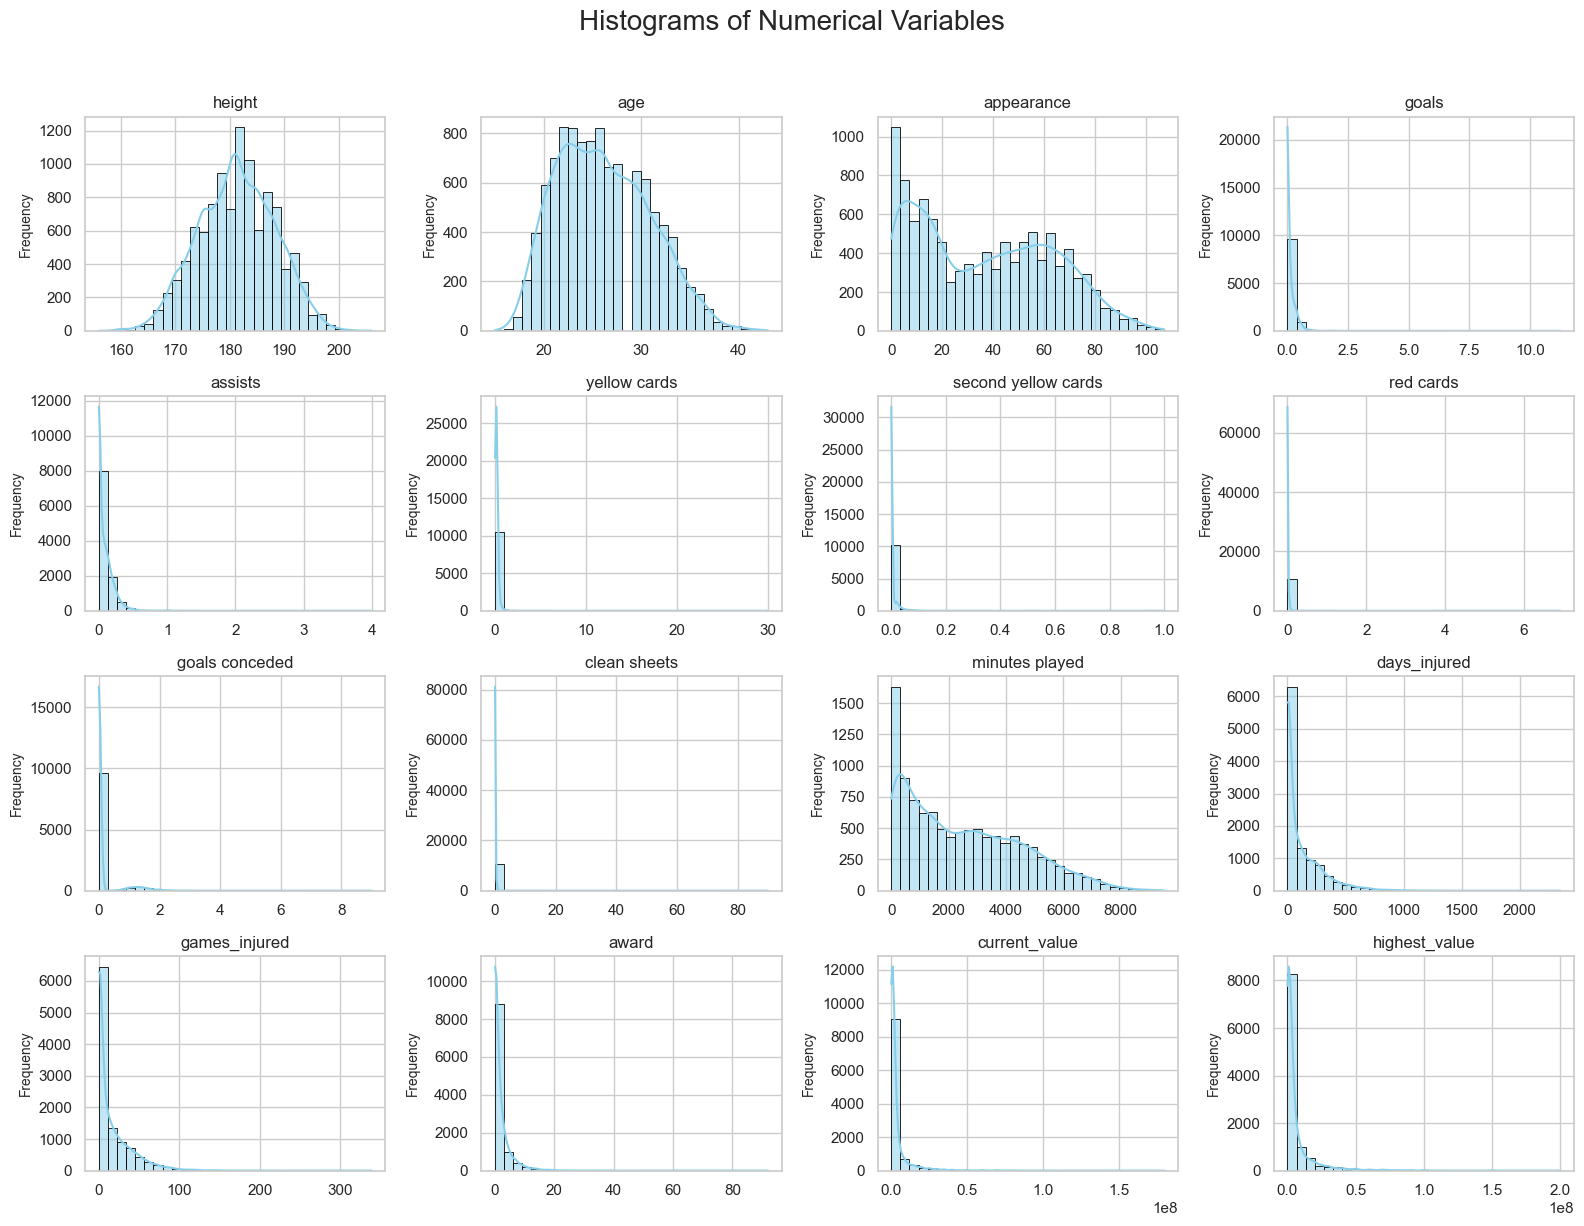

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of numerical columns to visualize
numerical_columns = [
    'height', 'age', 'appearance', 'goals', 'assists', 'yellow cards', 
    'second yellow cards', 'red cards', 'goals conceded', 'clean sheets', 
    'minutes played', 'days_injured', 'games_injured', 'award', 
    'current_value', 'highest_value'
]

# Set the aesthetic style of the plots
sns.set(style="whitegrid", palette="pastel")

# Set up the figure for histograms
plt.figure(figsize=(16, 12))  # Increased figure size for better spacing
plt.suptitle("Histograms of Numerical Variables", fontsize=20, y=1.02)  # Added a super title

# Loop through each numerical column and create histograms
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 4, i)  # Organize subplots in a 4x4 grid
    sns.histplot(football[col], bins=30, kde=True, color='skyblue', edgecolor='black')
    plt.title(col, fontsize=12)  # Add column name as title
    plt.xlabel("")  # Remove x-axis label for cleaner look
    plt.ylabel("Frequency", fontsize=10)  # Add y-axis label

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [158]:
football.drop(columns=["name","player"],inplace=True)

#### 2. Feature engineering

1. Feature scaling
2. Aggregation
3. One hot coding

In [159]:
football.head(2)

,team,position,height,age,appearance,goals,assists,yellow cards,second yellow cards,red cards,...,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger,penalty_flag
0,Manchester United,Goalkeeper,189.0,32.0,104,0.0,0.0,0.009585,0.0,0.0,...,0.335463,9390,42,5,13,15000000,70000000,1,0,0
1,Manchester United,Goalkeeper,196.0,30.0,15,0.0,0.0,0.069018,0.0,0.0,...,0.207055,1304,510,58,1,1500000,22000000,1,0,0


In [160]:
# Numerical Columns (Quantitative Features)
# These columns contain continuous or discrete numerical values used for statistical analysis,
# correlation studies, and machine learning models. They represent measurable quantities.

numerical_columns = [
    'height', 'age', 'appearance', 'goals', 'assists', 'yellow cards',
    'second yellow cards', 'red cards', 'goals conceded', 'clean sheets',
    'minutes played', 'days_injured', 'games_injured', 'award',
    'current_value', 'highest_value', 'position_encoded', 'winger', 'penalty_flag'
    
]

# Categorical Columns (Qualitative Features)
# These columns represent categories or labels. They are used for classification tasks, grouping,
# and often need to be transformed into numerical values
# during preprocessing for machine learning models.
categorical_columns = [
     'team', 'position'
]

In [161]:
categorical_columns

['team', 'position']

In [162]:
football['minutes_played'] = football['minutes played']
football = football.drop('minutes played', axis = 1)

In [163]:
# one hot coding
df = pd.get_dummies(football, columns=categorical_columns)

In [164]:
df.shape

(10629, 409)

In [165]:
df.head(2)

,height,age,appearance,goals,assists,yellow cards,second yellow cards,red cards,goals conceded,clean sheets,...,position_Defender Centre-Back,position_Defender Left-Back,position_Defender Right-Back,position_Goalkeeper,position_midfield,position_midfield-AttackingMidfield,position_midfield-CentralMidfield,position_midfield-DefensiveMidfield,position_midfield-LeftMidfield,position_midfield-RightMidfield
0,189.0,32.0,104,0.0,0.0,0.009585,0.0,0.0,1.217252,0.335463,...,False,False,False,True,False,False,False,False,False,False
1,196.0,30.0,15,0.0,0.0,0.069018,0.0,0.0,1.242331,0.207055,...,False,False,False,True,False,False,False,False,False,False


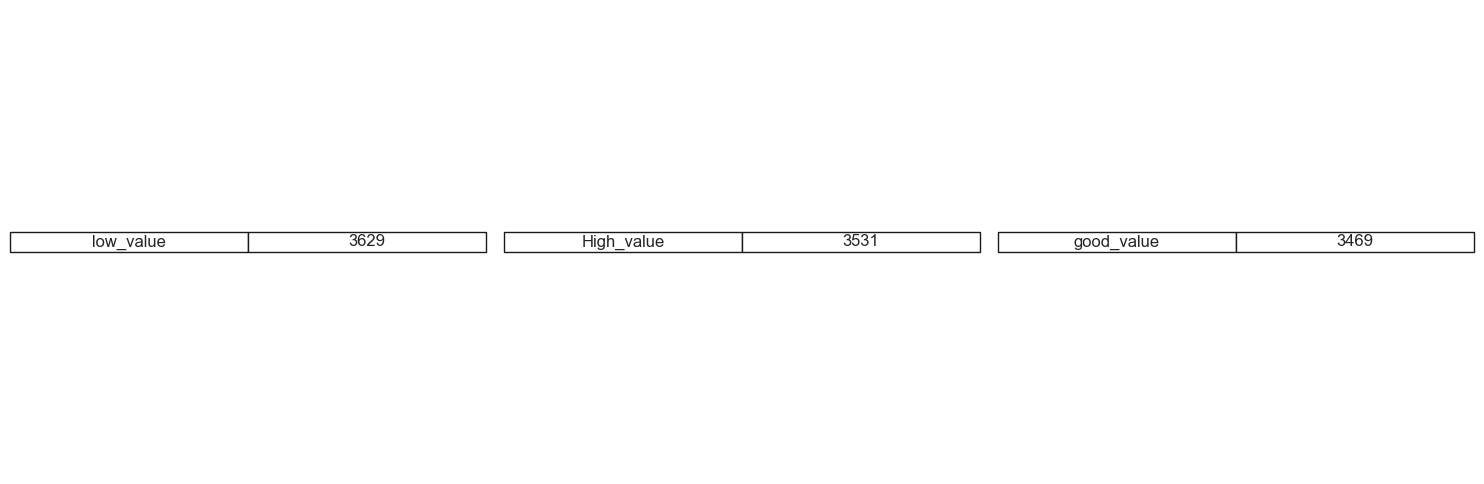

In [166]:
# Calculate the 35th and 70th percentiles of 'current_value'
p35, p75 = football['current_value'].quantile([0.35, 0.70])

# Function to categorize prices
def categorize_price(price):
    if price < p35:
        return 'low_value'
    elif price < p75:
        return 'good_value'
    else:
        return 'High_value'

# Apply the function to create a new column
football['current_value_category'] = football['current_value'].apply(categorize_price)

# Drop the original 'current_value' column
football.drop(columns=['current_value'], inplace=True)

# Display category distribution
# Category distribution counts
category_counts = football['current_value_category'].value_counts()

# Plot the tables for each category
fig, axes = plt.subplots(nrows=1, ncols=len(category_counts), figsize=(15, 5))

# Loop through the categories and their counts to create individual tables
for ax, (category, count) in zip(axes, category_counts.items()):
    ax.axis('off')
    ax.table(cellText=[[category, count]], loc="center", cellLoc='center', colLoc='center')

plt.tight_layout()
plt.show()



In [167]:
# Print percentiles and table charts for each category
print(f"Percentile 35 (p35): {p35}")
print(f"Percentile 70 (p75): {p75}\n")

Percentile 35 (p35): 450000.0
Percentile 70 (p75): 2000000.0



In [168]:
encoder = LabelEncoder()
football['current_value_category_encoded'] = encoder.fit_transform(football['current_value_category'])

In [169]:
football["current_value_category_encoded"]

0        0
1        1
2        1
3        0
4        0
        ..
10749    2
10750    2
10751    2
10752    2
10753    2
Name: current_value_category_encoded, Length: 10629, dtype: int32

#### 3. Feature selection

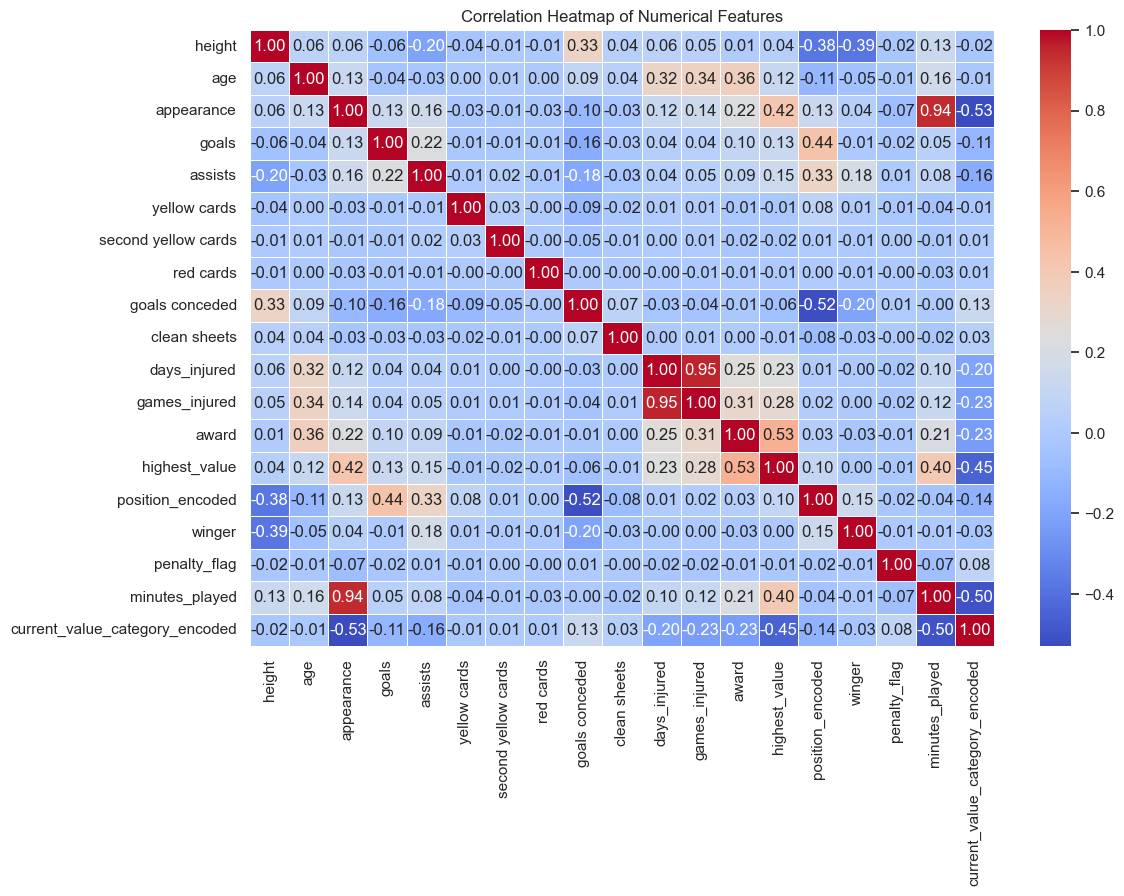

In [170]:
# Extract numerical columns from the DataFrame
numerical_columns = football.select_dtypes(include=['number']).columns

# Calculate the correlation matrix
correlation_matrix = football[numerical_columns].corr()

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Show the plot
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [171]:
# The features most correlated with 'current_value' are 'appearance' and 'minutes played', 
# both showing correlations around 0.4, followed by 'award'.
# Other positively correlated features include 'goals', 'assists', 'days_injured', and 'games_injured'.
# This indicates that player values are strongly influenced by their performance metrics.
# 'highest_value' shows a different correlation pattern.

In [172]:
correlation= football.corr(numeric_only=True)
print(correlation['current_value_category_encoded'].sort_values(ascending=False))

current_value_category_encoded    1.000000
goals conceded                    0.133166
penalty_flag                      0.076038
clean sheets                      0.032558
second yellow cards               0.007692
red cards                         0.007414
yellow cards                     -0.010539
age                              -0.012224
height                           -0.021117
winger                           -0.030586
goals                            -0.113933
position_encoded                 -0.136975
assists                          -0.164169
days_injured                     -0.195044
games_injured                    -0.226760
award                            -0.231888
highest_value                    -0.448440
minutes_played                   -0.500011
appearance                       -0.529165
Name: current_value_category_encoded, dtype: float64


In [173]:
# Set the correlation threshold
threshold = 0.15

# Filter the correlations
# We use `abs()` for absolute value to consider both strong positive and negative correlations
selected_features = correlation[abs(correlation['current_value_category_encoded']) > threshold]['current_value_category_encoded'].index
selected_features

Index(['appearance', 'assists', 'days_injured', 'games_injured', 'award',
       'highest_value', 'minutes_played', 'current_value_category_encoded'],
      dtype='object')

In [174]:
df = football[selected_features]

In [193]:
df.head(1)

,appearance,assists,days_injured,games_injured,award,highest_value,minutes_played,current_value_category_encoded
0,104,0.0,42,5,13,70000000,9390,0


In [194]:
df.columns

Index(['appearance', 'assists', 'days_injured', 'games_injured', 'award',
       'highest_value', 'minutes_played', 'current_value_category_encoded'],
      dtype='object')

#### 4. Prepare train and test data

In [176]:
# Prepare data
X = df.drop(['current_value_category_encoded'], axis=1)
y = df['current_value_category_encoded']

In [177]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=42)

# sacle the data
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [178]:
X.shape

(10629, 7)

## Buliding the Model

In [179]:
model = KNeighborsClassifier()

In [180]:
param_grid = {
    'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10]
}
grid_search = GridSearchCV(estimator=model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='f1_macro', 
                           verbose=1)

## Train the Model

In [181]:
# Fit the model on the training data
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='f1_macro', verbose=1)

In [182]:
grid_search.best_params_

{'n_neighbors': 10}

In [183]:
model = grid_search.best_estimator_

## Test the Model

In [184]:
# Predict and evaluate the model
y_pred = model.predict(X_test_scaled)

## Evaluating the Model 

In [185]:
# our benchmark model
base_model = round(df['current_value_category_encoded'].value_counts()[1]/df.shape[0]*100, 2)
base_model

32.64

1. Accurcy

In [186]:
# Train score
# Evaluate train set dt model
y_pred_train = model.predict(X_train_scaled)
accuracy = accuracy_score(y_train, y_pred_train)
print(f"Accurcy in Train dt: {accuracy:.2f}")
# Test score
# Evaluate test set dt model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accurcy in test dt: {accuracy:.2f}")

Accurcy in Train dt: 0.73
Accurcy in test dt: 0.66


##### Confusion matrix

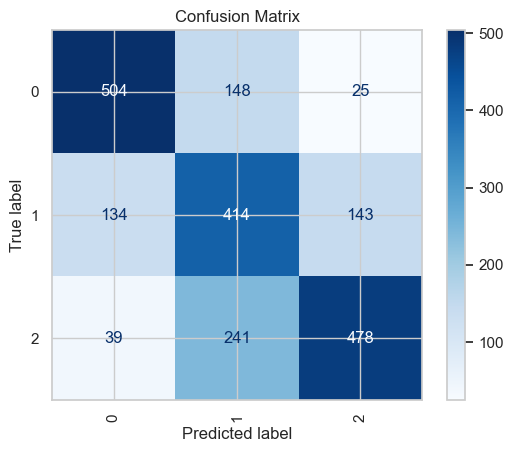

In [187]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=model.classes_,
                                        cmap="Blues",
                                        xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

In [188]:
print("Train classification report for best knn:")
print(f' {classification_report(y_train, y_pred_train, labels=list(model.classes_))}')
print("Test classification report for best knn: ")
print(f'{classification_report(y_test, y_pred, labels=list(model.classes_))}')

Train classification report for best knn:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81      2854
           1       0.62      0.67      0.64      2778
           2       0.77      0.72      0.74      2871

    accuracy                           0.73      8503
   macro avg       0.73      0.73      0.73      8503
weighted avg       0.73      0.73      0.73      8503

Test classification report for best knn: 
              precision    recall  f1-score   support

           0       0.74      0.74      0.74       677
           1       0.52      0.60      0.55       691
           2       0.74      0.63      0.68       758

    accuracy                           0.66      2126
   macro avg       0.67      0.66      0.66      2126
weighted avg       0.67      0.66      0.66      2126



2. Precision

In [189]:
# Calculate Precision
precision = precision_score(y_test, y_pred, average='macro')
print(f"Precision: {precision:.2f}")

Precision: 0.67


3. Recall

In [190]:
# Calculate Recall
recall = recall_score(y_test, y_pred, average='macro')
print(f"Recall: {recall:.2f}")

Recall: 0.66


4. F1-Score

In [191]:
# Calculate F1 Score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"F1 Score: {f1:.2f}")

F1 Score: 0.66


In [192]:
import joblib
joblib.dump(model, 'KNN.joblib')
joblib.dump(scaler, 'scaler1.joblib')


['scaler1.joblib']